# Fitting an aragonite P-V-T equation of state

This notebook uses the 64 aragonite observations printed in Table 3 of Martinez, Zhang, and Reeder (1996), [doi:10.2138/am-1996-5-608](https://doi.org/10.2138/am-1996-5-608), as a worked equation-of-state fitting example. It reproduces the paper's staged second-order Birch-Murnaghan analysis, demonstrates Peritheos fitting APIs, and shows why a numerical fit is inseparable from its residual and uncertainty definitions.

The table's `dV` column is the uncertainty of the diffraction lattice fit. It is **not** a complete uncertainty for the P-V-T state: the paper estimates pressure precision as better than 0.2 GPa and does not publish the complete pressure/temperature covariance. We therefore use unweighted pressure residuals for direct reproduction and use 0.2 GPa only as an illustrative common pressure scale when reporting chi-square. Notebook-derived parameters are diagnostics, not replacement catalog values.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from peritheos import Material, get_material_document
from peritheos.eos.rt import BM2, BM3
from peritheos.eos.thermal import ThermalReferenceStateEOS
from peritheos.fitting import fit_joint_eos, fit_rt_eos

plt.style.use("seaborn-v0_8-whitegrid")

candidates = [
    Path("data/martinez-1996-aragonite-table3.csv"),
    Path("docs/notebooks/data/martinez-1996-aragonite-table3.csv"),
]
data_path = next(path for path in candidates if path.exists())
data = np.genfromtxt(data_path, delimiter=",", names=True)
temperature = data["temperature_k"]
pressure = data["pressure_gpa"]
volume = data["volume_a3"]
volume_fit_sigma = data["volume_fit_sigma_a3"]

print(f"Loaded {len(data)} observations from {data_path}")
print(f"P range: {pressure.min():.2f}-{pressure.max():.2f} GPa")
print(f"T range: {temperature.min():.0f}-{temperature.max():.0f} K")

Loaded 64 observations from data/martinez-1996-aragonite-table3.csv
P range: 0.00-8.18 GPa
T range: 298-1273 K


## Inspect the observations

Pressure is plotted on the horizontal axis and conventional-cell volume on the vertical axis. Color identifies the reported isotherm. Repeated measurements at identical printed pressure and temperature sometimes differ by much more than their individual `dV` values; this is direct evidence that `dV` alone is not a complete statistical error model.

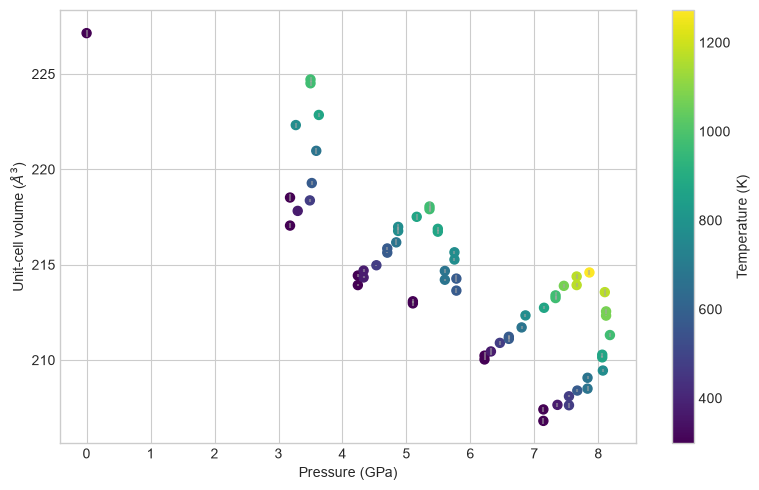

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
points = ax.scatter(pressure, volume, c=temperature, cmap="viridis", s=42)
ax.errorbar(
    pressure, volume, yerr=volume_fit_sigma, fmt="none", ecolor="0.65", alpha=0.55
)
ax.set(xlabel="Pressure (GPa)", ylabel=r"Unit-cell volume ($\AA^3$)")
fig.colorbar(points, ax=ax, label="Temperature (K)")
fig.tight_layout()
plt.show()

## Fit the 298 K reference isotherm

The paper's staged analysis fixes $K'_0=4$, making each isotherm a second-order Birch-Murnaghan fit. `fit_rt_eos` uses Jacobian-scaled nonlinear least squares. With no sigma supplied, residuals remain in GPa and the fit is an ordinary unweighted pressure-residual fit.

In [3]:
room_temperature = temperature == 298.0
fit_298 = fit_rt_eos(
    BM2,
    volume=volume[room_temperature],
    pressure=pressure[room_temperature],
    initial={"V0": 227.5, "K0": 65.0},
    bounds={"V0": (220.0, 235.0), "K0": (20.0, 120.0)},
)
print(fit_298.summary())
print("Published Table 6: V0 = 227.5(8) A^3, K0 = 64.81(348) GPa")

FitResult (BM2)
Success: True (status 2)
Message: `ftol` termination condition is satisfied.

Parameters:
  Name                Value      Std. error  Status
  V0                227.719        0.674377  free
  K0                63.9442         3.05748  free

Diagnostics:
  chi-square: 0.541289
  reduced chi-square: 0.0601433
  degrees of freedom: 9
  AIC: -29.1287
  BIC: -28.3329

Solver:
  loss: linear
  f_scale: 1
  function evaluations: 4
  cost: 0.270645
  optimality: 1.856e-08
Published Table 6: V0 = 227.5(8) A^3, K0 = 64.81(348) GPa


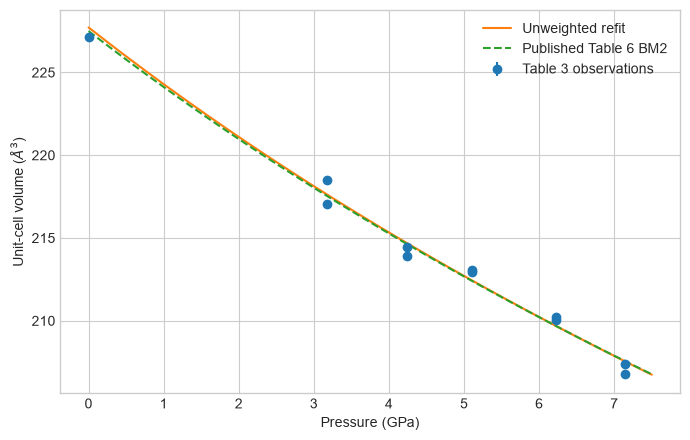

In [4]:
pressure_grid = np.linspace(0.0, 7.5, 250)
published_298 = BM2(V0=227.5, K0=64.81)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    pressure[room_temperature],
    volume[room_temperature],
    yerr=volume_fit_sigma[room_temperature],
    fmt="o",
    label="Table 3 observations",
)
ax.plot(pressure_grid, fit_298.model.volume(pressure_grid), label="Unweighted refit")
ax.plot(
    pressure_grid,
    published_298.volume(pressure_grid),
    "--",
    label="Published Table 6 BM2",
)
ax.set(xlabel="Pressure (GPa)", ylabel=r"Unit-cell volume ($\AA^3$)")
ax.legend()
fig.tight_layout()
plt.show()

## Repeat the BM2 fit along each published isotherm

Table 6 reports independent $V_{0,T}$ and $K_{0,T}$ fits through 973 K. The loop below applies the same BM2 structure to the rounded Table 3 values. Small differences from Table 6 are expected because the paper does not state the exact weights and likely used unrounded diffraction and NaCl calibration results.

In [5]:
table6_temperature = np.array([298, 373, 473, 573, 673, 773, 873, 973], dtype=float)
table6_k0 = np.array([64.81, 68.09, 62.8, 60.7, 55.45, 54.8, 55.7, 54.8])
table6_k0_sigma = np.array([3.48, 4.6, 3.8, 4.7, 3.16, 4.09, 1.8, 2.51])
table6_v0 = np.array([227.5, 228.0, 229.6, 231.2, 232.9, 234.3, 235.6, 237.1])
table6_v0_sigma = np.array([0.8, 0.48, 0.4, 0.6, 0.5, 0.6, 0.3, 0.5])

isotherm_fits = []
for current_temperature, initial_v0, initial_k0 in zip(
    table6_temperature, table6_v0, table6_k0
):
    selected = temperature == current_temperature
    result = fit_rt_eos(
        BM2,
        volume=volume[selected],
        pressure=pressure[selected],
        initial={"V0": initial_v0, "K0": initial_k0},
    )
    isotherm_fits.append(result)

print(" T/K   published V0   refit V0   published K0   refit K0")
for current_temperature, published_v0, published_k0, result in zip(
    table6_temperature, table6_v0, table6_k0, isotherm_fits
):
    print(
        f"{current_temperature:4.0f} {published_v0:14.2f}"
        f" {result.parameters['V0']:10.2f} {published_k0:14.2f}"
        f" {result.parameters['K0']:10.2f}"
    )

 T/K   published V0   refit V0   published K0   refit K0
 298         227.50     227.72          64.81      63.94
 373         228.00     227.37          68.09      68.09
 473         229.60     229.50          62.80      62.75
 573         231.20     231.26          60.70      60.70
 673         232.90     233.66          55.45      55.43
 773         234.30     233.12          54.80      60.78
 873         235.60     235.81          55.70      55.70
 973         237.10     237.40          54.80      54.94


## Recover the staged thermal coefficients

Equation 2 makes $K_{0,T}$ linear in temperature. Equation 3 makes $V_{0,T}$ directly linear through a mean expansion coefficient, rather than exponentially integrating a constant instantaneous expansivity. Regressing the printed Table 6 values independently reproduces the row-4 thermal coefficients.

In [6]:
delta_temperature = table6_temperature - 298.0
volume_slope, volume_intercept = np.polyfit(delta_temperature, table6_v0, 1)
alpha_bar = volume_slope / volume_intercept
k0_slope_unweighted, k0_intercept_unweighted = np.polyfit(
    delta_temperature, table6_k0, 1
)
k0_slope_weighted, k0_intercept_weighted = np.polyfit(
    delta_temperature, table6_k0, 1, w=1.0 / table6_k0_sigma
)

print(f"Mean expansion from Table 6: {alpha_bar:.7e} K^-1")
print("Published:                     6.5(1)e-5 K^-1")
print(f"Unweighted dK0/dT:           {k0_slope_unweighted:.5f} GPa/K")
print(f"Error-weighted dK0/dT:       {k0_slope_weighted:.5f} GPa/K")
print("Published:                    -0.018(2) GPa/K")

Mean expansion from Table 6: 6.4835049e-05 K^-1
Published:                     6.5(1)e-5 K^-1
Unweighted dK0/dT:           -0.01969 GPa/K
Error-weighted dK0/dT:       -0.01702 GPa/K
Published:                    -0.018(2) GPa/K


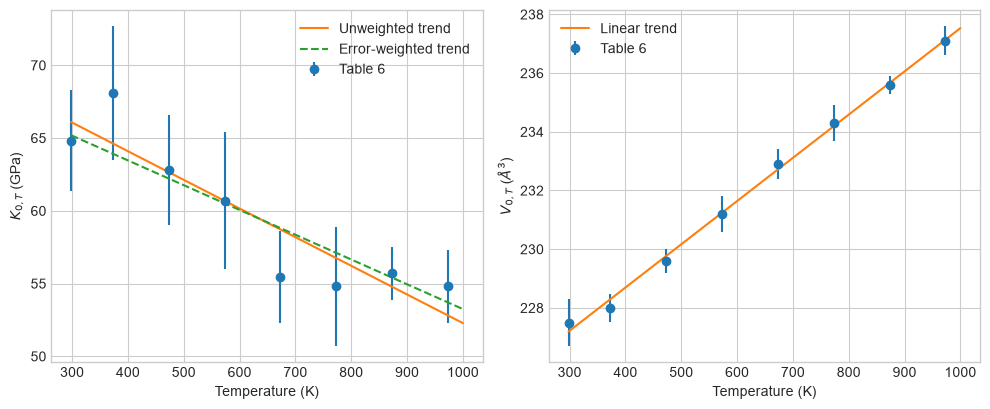

In [7]:
temperature_grid = np.linspace(298.0, 1000.0, 250)
delta_grid = temperature_grid - 298.0
fig, (ax_k, ax_v) = plt.subplots(1, 2, figsize=(10, 4.2))
ax_k.errorbar(
    table6_temperature, table6_k0, yerr=table6_k0_sigma, fmt="o", label="Table 6"
)
ax_k.plot(
    temperature_grid,
    k0_intercept_unweighted + k0_slope_unweighted * delta_grid,
    label="Unweighted trend",
)
ax_k.plot(
    temperature_grid,
    k0_intercept_weighted + k0_slope_weighted * delta_grid,
    "--",
    label="Error-weighted trend",
)
ax_k.set(xlabel="Temperature (K)", ylabel=r"$K_{0,T}$ (GPa)")
ax_k.legend()

ax_v.errorbar(
    table6_temperature, table6_v0, yerr=table6_v0_sigma, fmt="o", label="Table 6"
)
ax_v.plot(
    temperature_grid, volume_intercept + volume_slope * delta_grid, label="Linear trend"
)
ax_v.set(xlabel="Temperature (K)", ylabel=r"$V_{0,T}$ ($\AA^3$)")
ax_v.legend()
fig.tight_layout()
plt.show()

## Use the validated catalog record

Peritheos stores the staged result as a BM2 reference isotherm composed with `ThermalReferenceStateEOS`. Its `reference_volume_law="linear_temperature"` preserves Equation 3 exactly. The curves below are the database record, not a notebook refit.

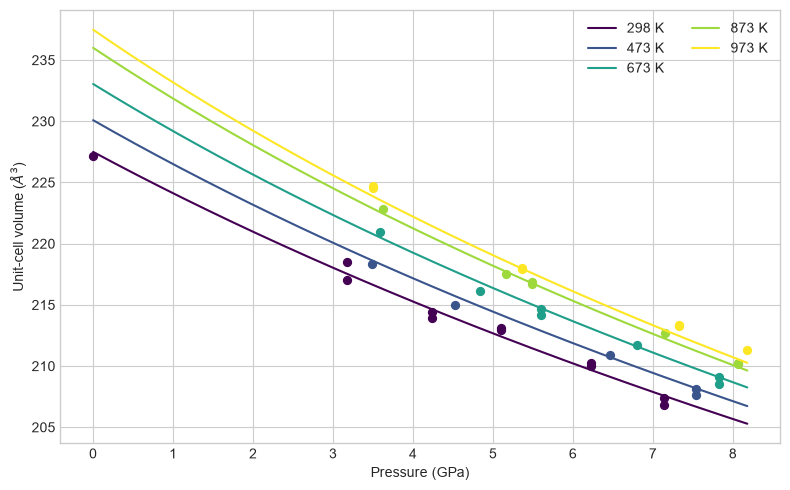

In [8]:
aragonite_material = Material.from_eosmat(get_material_document("aragonite"))
aragonite = aragonite_material.get_eos_record("aragonite_martinez_1996_bm2_2")
pressure_grid = np.linspace(0.0, 8.18, 250)
curve_temperatures = np.array([298.0, 473.0, 673.0, 873.0, 973.0])
colors = plt.cm.viridis(
    (curve_temperatures - curve_temperatures.min()) / np.ptp(curve_temperatures)
)
fig, ax = plt.subplots(figsize=(8, 5))
for current_temperature, color in zip(curve_temperatures, colors):
    selected = temperature == current_temperature
    ax.scatter(pressure[selected], volume[selected], color=color, s=32)
    ax.plot(
        pressure_grid,
        aragonite.volume(pressure_grid, current_temperature, check_validity=False),
        color=color,
        label=f"{current_temperature:.0f} K",
    )
ax.set(xlabel="Pressure (GPa)", ylabel=r"Unit-cell volume ($\AA^3$)")
ax.legend(ncols=2)
fig.tight_layout()
plt.show()

## Diagnostic joint fit and parameter scaling

For comparison, the paper also reports a six-parameter global BM3 model with $\alpha(T)=\alpha_0+\alpha_1T$. The fitted reference volume is missing from Table 7, so this model is not included in the catalog. The diagnostic fit below starts from the five printed coefficients and the Table 6 reference volume. Tiny coefficients are exposed to the optimizer as order-one multipliers; Peritheos additionally applies Jacobian scaling. This avoids a numerical step-size artifact while retaining physical units in the constructed model.

In [9]:
class ScaledIntegratedLinearExpansion(ThermalReferenceStateEOS):
    def __init__(self, rt_eos, Tr, dK_dT, alpha0_e5, alpha1_e9):
        self.alpha0_e5 = alpha0_e5
        self.alpha1_e9 = alpha1_e9
        super().__init__(
            rt_eos=rt_eos,
            Tr=Tr,
            alpha0=alpha0_e5 * 1.0e-5,
            alpha1=alpha1_e9 * 1.0e-9,
            dK_dT=dK_dT,
            thermal_expansion_law="linear_temperature",
        )


joint_fit = fit_joint_eos(
    ScaledIntegratedLinearExpansion,
    BM3,
    volume=volume,
    temperature=temperature,
    pressure=pressure,
    initial={
        "rt_eos.V0": 227.5,
        "rt_eos.K0": 65.4,
        "rt_eos.K0_prime": 2.7,
        "dK_dT": -0.013,
        "alpha0_e5": 6.5,
        "alpha1_e9": 3.1,
    },
    fixed={"Tr": 298.0},
    bounds={
        "rt_eos.V0": (220.0, 235.0),
        "rt_eos.K0": (20.0, 120.0),
        "rt_eos.K0_prime": (0.0, 10.0),
        "dK_dT": (-0.05, 0.02),
        "alpha0_e5": (-10.0, 20.0),
        "alpha1_e9": (-20.0, 100.0),
    },
    pressure_sigma=np.full_like(pressure, 0.2),
    absolute_sigma=True,
)
print(joint_fit.summary())
print("Published coefficients (V0 omitted):")
print("K0=65.4, K0_prime=2.7, dK_dT=-0.013, alpha0_e5=6.5, alpha1_e9=3.1")

FitResult (ScaledIntegratedLinearExpansion)
Success: True (status 2)
Message: `ftol` termination condition is satisfied.

Parameters:
  Name                      Value      Std. error  Status
  rt_eos.V0               227.481        0.633521  free
  rt_eos.K0               65.2681         5.68502  free
  rt_eos.K0_prime         3.83424         1.24519  free
  dK_dT                -0.0140223      0.00558367  free
  alpha0_e5               4.45104        0.630537  free
  alpha1_e9               27.2251         14.4976  free
  Tr                          298               0  fixed

Diagnostics:
  chi-square: 40.8672
  reduced chi-square: 0.704607
  degrees of freedom: 58
  AIC: -16.7076
  BIC: -3.75426

Solver:
  loss: linear
  f_scale: 1
  function evaluations: 8
  cost: 20.4336
  optimality: 0.000204605
Published coefficients (V0 omitted):
K0=65.4, K0_prime=2.7, dK_dT=-0.013, alpha0_e5=6.5, alpha1_e9=3.1


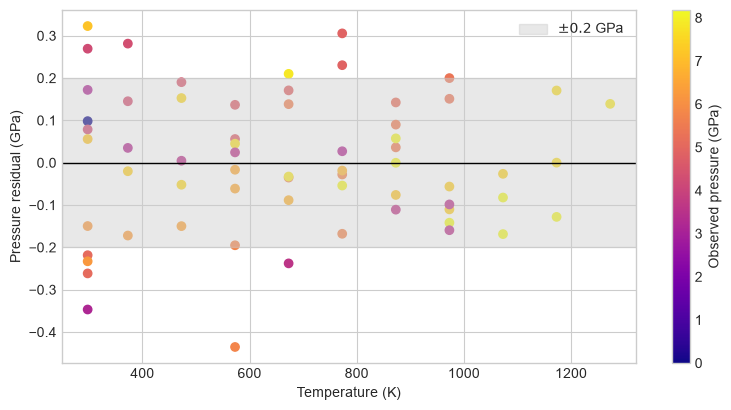

Pressure RMSE: 0.1598 GPa
chi-square for illustrative sigma_P=0.2 GPa: 40.87
reduced chi-square: 0.705
Jacobian-derived maximum |correlation|: 0.933


In [10]:
predicted_pressure = joint_fit.model.pressure(volume, temperature)
residual = predicted_pressure - pressure
fig, ax = plt.subplots(figsize=(8, 4.2))
residual_points = ax.scatter(temperature, residual, c=pressure, cmap="plasma")
ax.axhline(0.0, color="black", linewidth=1)
ax.axhspan(-0.2, 0.2, color="0.8", alpha=0.45, label=r"$\pm 0.2$ GPa")
ax.set(xlabel="Temperature (K)", ylabel="Pressure residual (GPa)")
ax.legend()
fig.colorbar(residual_points, ax=ax, label="Observed pressure (GPa)")
fig.tight_layout()
plt.show()

print(f"Pressure RMSE: {np.sqrt(np.mean(residual**2)):.4f} GPa")
print(f"chi-square for illustrative sigma_P=0.2 GPa: {joint_fit.chi_square:.2f}")
print(f"reduced chi-square: {joint_fit.reduced_chi_square:.3f}")
print(
    f"Jacobian-derived maximum |correlation|: {np.max(np.abs(joint_fit.correlation - np.eye(len(joint_fit.free_parameters)))):.3f}"
)

## What this example establishes

1. The 298 K BM2 fit and the staged Table 6 thermal trends are independently reproducible from the publication.
2. Residual choice, weighting, rounding, and covariance materially affect fitted EOS coefficients.
3. Parameter scaling is necessary but does not reconcile the printed global HT-BM3 coefficients with the printed dataset.
4. A small change in pressure RMSE can accompany a large parameter shift when the model is strongly correlated.
5. A fit produced here should not be promoted to a material record unless its equation, reference state, uncertainty model, and provenance are independently defensible.